# Project Objective: House Price Prediction

This notebook aims to build a house price prediction model. We will cover the following steps:
1.  **Data Loading and Initial Exploration**: Load the dataset and perform initial checks on its structure, types, and summary statistics.
2.  **Data Cleaning**: Handle missing values, identify and remove duplicate rows, and manage outliers to ensure data quality.
3.  **Feature Engineering**: Standardize and normalize features, and apply one-hot encoding to categorical variables.
4.  **Model Training and Evaluation**: Split the data into training and testing sets, train a Linear Regression model, and evaluate its performance using key metrics and visualizations.


## Data Cleaning and Preprocessing for Housing Data

In [ ]:
# Import necessary libraries for data manipulation and numerical operations
import pandas as pd
import numpy as np
#import matplotlib.pyplot as plt # Matplotlib is imported later when needed for plots

### Import Libraries

In [ ]:
# Import the 'files' module from google.colab to enable file uploads in Colab environment
from google.colab import files

# Prompt the user to upload files, which will be stored in the 'uploaded' dictionary
uploaded = files.upload()

Saving messy_housing_data.csv to messy_housing_data.csv


### Upload Data

In [ ]:
# Load the uploaded CSV file into a pandas DataFrame named 'df'
df = pd.read_csv('messy_housing_data.csv')

### Load Data into DataFrame

In [ ]:
# Remove 21 random rows from the DataFrame to ensure unique output for demonstration purposes
df = df.drop(np.random.choice(df.index, 21 , replace=False))

### Remove Random Rows (for unique output generation)

In [ ]:
# Display the first 5 rows of the DataFrame to get an initial overview of the data
df.head()

,area_sqft,bedrooms,bathrooms,year_built,price,location
0,2696,4.0,1,1962.0,2068779.98,austin
1,2017,6.0,4,2008.0,1539208.46,San Francisco
2,1592,3.0,3,1991.0,557909.7,San Francisco
3,3358,2.0,4,1914.0,NaN,chicago
4,1624,2.0,5,1935.0,716945.96,New York City


### Display First 5 Rows

In [ ]:
# Display the last 5 rows of the DataFrame to check the end of the dataset
df.tail()

,area_sqft,bedrooms,bathrooms,year_built,price,location
414,1724,2.0,2,1912.0,851969.88,miami
415,3674,5.0,5,NaN,2664238.68,l.a.
416,939,3.0,5,1965.0,491056.77,Los Angeles
418,3279,5.0,5,1935.0,1308383.3,Chicago
419,1139,2.0,3,1915.0,496344.73,nyc




```
# This is formatted as code
```

### Display Last 5 Rows

In [ ]:
# Print the type of the 'df' object to confirm it is a pandas DataFrame
print(type(df))

<class 'pandas.core.frame.DataFrame'>


### Check DataFrame Type

In [ ]:
# Display the shape of the DataFrame (number of rows, number of columns)
df.shape

(399, 6)

### Get DataFrame Shape

In [ ]:
# Display the column names of the DataFrame
df.columns

Index(['area_sqft', 'bedrooms', 'bathrooms', 'year_built', 'price',
       'location'],
      dtype='object')

### Get Column Names

In [ ]:
# Convert the column names to a list for easier viewing and manipulation
list(df.columns)

['area_sqft', 'bedrooms', 'bathrooms', 'year_built', 'price', 'location']

### Convert Column Names to List

In [ ]:
# Display the data types of each column in the DataFrame
df.dtypes

,0
area_sqft,int64
bedrooms,float64
bathrooms,int64
year_built,float64
price,object
location,object


### Check Data Types

In [ ]:
# Display a concise summary of the DataFrame, including data types, non-null values, and memory usage
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 399 entries, 0 to 419
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   area_sqft   399 non-null    int64  
 1   bedrooms    378 non-null    float64
 2   bathrooms   399 non-null    int64  
 3   year_built  363 non-null    float64
 4   price       354 non-null    object 
 5   location    399 non-null    object 
dtypes: float64(2), int64(2), object(2)
memory usage: 21.8+ KB


### Get DataFrame Info

In [ ]:
# Generate descriptive statistics for numerical columns, including count, mean, std, min, max, and quartiles
df.describe()

,area_sqft,bedrooms,bathrooms,year_built
count,399.000000,378.000000,399.000000,363.000000
mean,2612.310777,3.597884,3.035088,1960.256198
std,1322.629275,2.417267,1.454078,37.694071
min,-100.000000,1.000000,1.000000,1900.000000
25%,1454.000000,2.000000,2.000000,1927.000000
50%,2644.000000,3.000000,3.000000,1959.000000
75%,3691.500000,5.000000,4.000000,1994.000000
max,4999.000000,20.000000,5.000000,2026.000000


### Describe Numerical Columns

In [ ]:
# Generate descriptive statistics for all columns, including categorical data
df.describe(include='all')

,area_sqft,bedrooms,bathrooms,year_built,price,location
count,399.000000,378.000000,399.000000,363.000000,354,399
unique,NaN,NaN,NaN,NaN,332,42
top,NaN,NaN,NaN,NaN,unavailable,san francisco
freq,NaN,NaN,NaN,NaN,7,28
mean,2612.310777,3.597884,3.035088,1960.256198,NaN,NaN
std,1322.629275,2.417267,1.454078,37.694071,NaN,NaN
min,-100.000000,1.000000,1.000000,1900.000000,NaN,NaN
25%,1454.000000,2.000000,2.000000,1927.000000,NaN,NaN
50%,2644.000000,3.000000,3.000000,1959.000000,NaN,NaN
75%,3691.500000,5.000000,4.000000,1994.000000,NaN,NaN


### Describe All Columns

In [ ]:
# Display 5 random rows from the DataFrame to get a diverse sample of the data
df.sample(5)

,area_sqft,bedrooms,bathrooms,year_built,price,location
163,1348,1.0,1,1912.0,738263.18,Miami
90,863,2.0,4,1940.0,212647.47,san francisco
52,2397,3.0,3,1960.0,790682.37,san francisco
216,3216,3.0,1,2018.0,2032036.44,Austin
305,3808,2.0,1,1942.0,2084071.95,San Francisco


### Display Sample Rows

In [ ]:
# Print the total number of rows in the DataFrame
print("Number of Rows:", df.shape[0])

Number of Rows: 399


### Display Number of Rows

In [ ]:
# Re-display the first 5 rows to confirm previous operations haven't changed the head
df.head()

,area_sqft,bedrooms,bathrooms,year_built,price,location
0,2696,4.0,1,1962.0,2068779.98,austin
1,2017,6.0,4,2008.0,1539208.46,San Francisco
2,1592,3.0,3,1991.0,557909.7,San Francisco
3,3358,2.0,4,1914.0,NaN,chicago
4,1624,2.0,5,1935.0,716945.96,New York City


### Re-display First 5 Rows

In [ ]:
# Check for null values in each cell of the DataFrame, returning a boolean DataFrame
df.isnull()

,area_sqft,bedrooms,bathrooms,year_built,price,location
0,False,False,False,False,False,False
1,False,False,False,False,False,False
2,False,False,False,False,False,False
3,False,False,False,False,True,False
4,False,False,False,False,False,False
...,...,...,...,...,...,...
414,False,False,False,False,False,False
415,False,False,False,True,False,False
416,False,False,False,False,False,False
418,False,False,False,False,False,False


### Check for Null Values

In [ ]:
# Count the number of null values per column
df.isnull().sum()

,0
area_sqft,0
bedrooms,21
bathrooms,0
year_built,36
price,45
location,0


### Count Null Values Per Column

In [ ]:
# Calculate the total number of null values across the entire DataFrame
df.isnull().sum().sum()

np.int64(102)

### Count Total Null Values

In [ ]:
# Calculate the percentage of missing values for each column
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage

,0
area_sqft,0.000000
bedrooms,5.263158
bathrooms,0.000000
year_built,9.022556
price,11.278195
location,0.000000


### Calculate Missing Value Percentage

In [ ]:
# Identify and display only those columns that have missing values
missing = df.isnull().sum()

missing[missing > 0]

,0
bedrooms,21
year_built,36
price,45


### Display Columns with Missing Values

In [ ]:
# Calculate and sort missing value percentages in descending order for clearer prioritization
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage = missing_percentage.sort_values(ascending=False)

missing_percentage

,0
price,11.278195
year_built,9.022556
bedrooms,5.263158
area_sqft,0.000000
bathrooms,0.000000
location,0.000000


### Display Sorted Missing Value Percentages

In [ ]:
# Create a summary table showing the count and percentage of missing values for each relevant column
missing_summary=pd.DataFrame({'missing values':df.isnull().sum(),
'percantage':(df.isnull().sum()/len(df))*100})
missing_summary=missing_summary[missing_summary['missing values']>0]
missing_summary

,missing values,percantage
bedrooms,21,5.263158
year_built,36,9.022556
price,45,11.278195


### Generate Missing Values Summary Table

In [ ]:
# Create a copy of the original DataFrame to perform cleaning operations, preserving the original data
df_clean=df.copy()

### Create a Clean DataFrame Copy

In [ ]:
# Check the null values in the newly created clean DataFrame copy
df_clean.isnull().sum()

,0
area_sqft,0
bedrooms,21
bathrooms,0
year_built,36
price,45
location,0


### Check Null Values in Clean DataFrame

In [ ]:
# Specifically check null values for 'price', 'year_built', and 'bedrooms' columns
df_clean[['price','year_built','bedrooms']].isnull().sum()

,0
price,45
year_built,36
bedrooms,21


### Check Null Values in Specific Columns of Clean DataFrame

In [ ]:
# Impute missing 'year_built' values with the median of the column
df_clean['year_built'] = df_clean['year_built'].fillna(df_clean['year_built'].median())

# Impute missing 'bedrooms' values with the median of the column
df_clean['bedrooms'] = df_clean['bedrooms'].fillna(df_clean['bedrooms'].median())
# Convert 'price' column to numeric, coercing errors to NaN, then fill remaining NaNs with median
df_clean['price']=pd.to_numeric(df_clean['price'],errors='coerce')
df_clean['price'] = df_clean['price'].fillna(df_clean['price'].median())

### Fill Missing Values

In [ ]:
# Verify that all missing values have been handled by checking the sum of nulls per column
df_clean.isnull().sum()

,0
area_sqft,0
bedrooms,0
bathrooms,0
year_built,0
price,0
location,0


### Verify No Missing Values Remain

In [ ]:
# Display the current dimensions (rows, columns) of the cleaned DataFrame
print("Number of Rows:", df_clean.shape[0])
print("Number of Columns:", df_clean.shape[1])

Number of Rows: 399
Number of Columns: 6


### Display Clean DataFrame Dimensions

In [ ]:
# Identify duplicated rows in the DataFrame, returning a boolean Series
df_clean.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
414,True
415,True
416,True
418,True


### Check for Duplicated Rows

In [ ]:
# Count the total number of duplicated rows in the DataFrame
df_clean.duplicated().sum()

np.int64(16)

### Count Duplicated Rows

In [ ]:
# Filter and display the actual duplicated rows in the DataFrame
duplicate_rows = df_clean[df_clean.duplicated()]

duplicate_rows

,area_sqft,bedrooms,bathrooms,year_built,price,location
400,3857,1.0,4,1970.0,1121087.17,los angeles
402,4360,6.0,3,1950.0,2551135.51,New York city
403,650,3.0,2,1959.0,136580.26,New York City
404,1974,1.0,5,1959.0,1147299.91,New York city
406,2266,1.0,3,1917.0,850749.66,Chicago
407,4281,4.0,4,1976.0,1871382.95,Bostan
408,976,3.0,2,2004.0,287451.49,los angeles
409,2256,3.0,4,1937.0,1763039.92,sf
410,3729,1.0,2,1913.0,1489205.48,l.a.
411,2129,5.0,1,2022.0,1108994.39,san francisco


### Display Duplicated Rows

In [ ]:
# Remove all duplicated rows from the DataFrame, keeping only the first occurrence
df_clean = df_clean.drop_duplicates()

### Drop Duplicated Rows

In [ ]:
# Verify that all duplicated rows have been removed
df_clean.duplicated().sum()

np.int64(0)

### Verify No Duplicates Remain

In [ ]:
# Compare the shape of the DataFrame before and after removing duplicates
print("Shape Before Removing Duplicates:", df.shape)

print("Shape After Removing Duplicates:", df_clean.shape)

Shape Before Removing Duplicates: (399, 6)
Shape After Removing Duplicates: (383, 6)


### Visulaizing Finding outliers

In [ ]:
# Display the first 5 rows of the clean DataFrame after handling duplicates
df_clean.head()

,area_sqft,bedrooms,bathrooms,year_built,price,location
0,2696,4.0,1,1962.0,2068779.98,austin
1,2017,6.0,4,2008.0,1539208.46,San Francisco
2,1592,3.0,3,1991.0,557909.70,San Francisco
3,3358,2.0,4,1914.0,1180883.15,chicago
4,1624,2.0,5,1935.0,716945.96,New York City


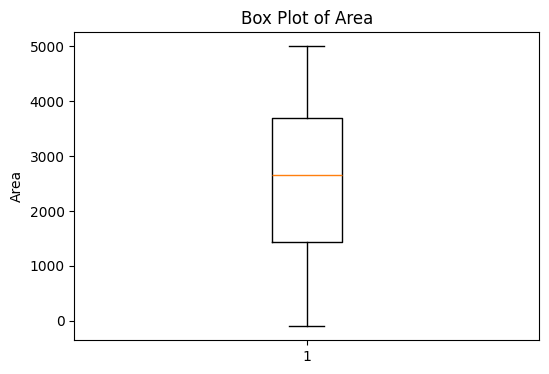

In [ ]:
# Import matplotlib for plotting
import matplotlib.pyplot as plt

# Create a box plot to visualize the distribution and outliers of 'area_sqft'
plt.figure(figsize=(6,4))
plt.boxplot(df_clean['area_sqft'])
plt.title("Box Plot of Area")
plt.ylabel("Area")
plt.show()

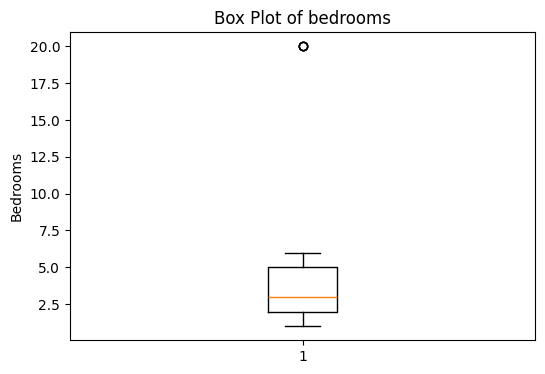

In [ ]:
# Create a box plot to visualize the distribution and outliers of 'bedrooms'
plt.figure(figsize=(6,4))
plt.boxplot(df_clean['bedrooms'])
plt.title("Box Plot of bedrooms")
plt.ylabel("Bedrooms")
plt.show()

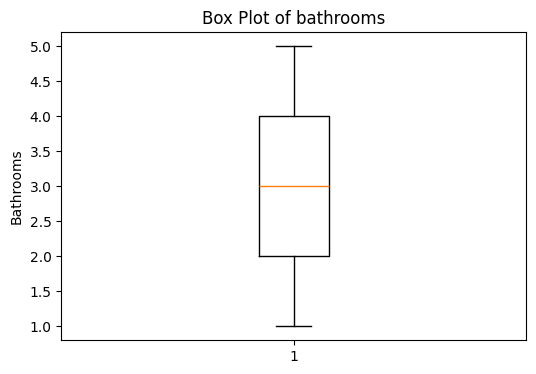

In [ ]:
# Create a box plot to visualize the distribution and outliers of 'bathrooms'
plt.figure(figsize=(6,4))
plt.boxplot(df_clean['bathrooms'])
plt.title("Box Plot of bathrooms")
plt.ylabel("Bathrooms")
plt.show()

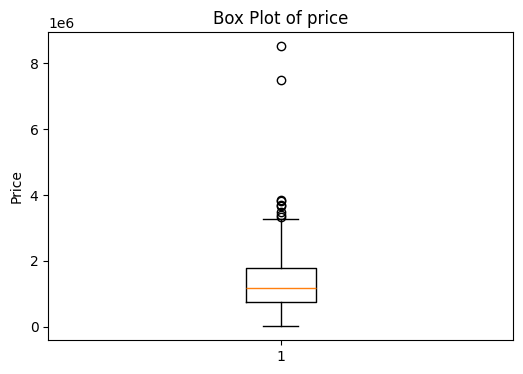

In [ ]:
# Create a box plot to visualize the distribution and outliers of 'price'
plt.figure(figsize=(6,4))
plt.boxplot(df_clean['price'])
plt.title("Box Plot of price")
plt.ylabel("Price")
plt.show()

### Handling ouliers of price

In [ ]:
# Calculate the first quartile (Q1) for the 'price' column
Q1 = df_clean['price'].quantile(0.25)

# Calculate the third quartile (Q3) for the 'price' column
Q3 = df_clean['price'].quantile(0.75)

# Calculate the Interquartile Range (IQR)
IQR = Q3 - Q1

# Calculate the lower bound for outlier detection
lower_limit = Q1 - 1.5 * IQR

# Calculate the upper bound for outlier detection
upper_limit = Q3 + 1.5 * IQR

# Print the calculated lower and upper limits for price outliers
print("Lower Limit :", lower_limit)
print("Upper Limit :", upper_limit)

Lower Limit : -780799.7925000002
Upper Limit : 3297770.1875


In [ ]:
# Filter the DataFrame to identify and display rows containing 'price' outliers
price_outliers = df_clean[
    (df_clean['price'] < lower_limit) |
    (df_clean['price'] > upper_limit)
]

price_outliers

,area_sqft,bedrooms,bathrooms,year_built,price,location
10,4896,5.0,1,1994.0,3830378.09,l.a.
165,4679,4.0,3,1924.0,3674840.20,Chicago
191,4973,6.0,1,2007.0,3849794.96,austin
245,4596,4.0,1,1996.0,3384779.81,New York City
283,3748,2.0,3,1920.0,7496000.00,AUSTIN
339,4260,6.0,5,1959.0,8520000.00,Austin
359,4748,1.0,5,1985.0,3472565.82,austin
369,4304,1.0,3,1953.0,3345120.68,sf
376,4880,3.0,3,2004.0,3709981.28,boston


In [ ]:
# Remove rows that fall outside the calculated lower and upper limits for 'price'
df_clean = df_clean[
    (df_clean['price'] >= lower_limit) &
    (df_clean['price'] <= upper_limit)
]

### Size comparison after removing outliers

In [ ]:
# Compare the DataFrame's shape before and after removing price outliers
print("Shape Before:", df.shape)

print("Shape After :", df_clean.shape)

Shape Before: (399, 6)
Shape After : (374, 6)


### VERIFYING USING BOXPLOT AGAIN

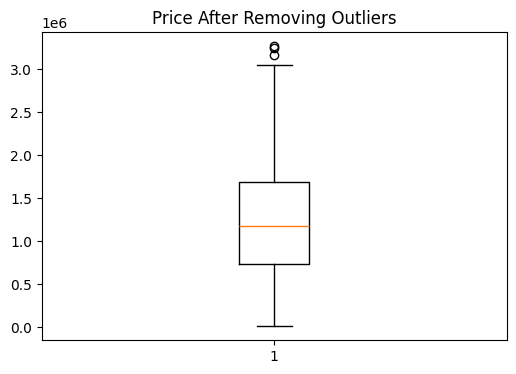

In [ ]:
# Re-generate the box plot for 'price' to visualize the distribution after outlier removal
plt.figure(figsize=(6,4))
plt.boxplot(df_clean['price'])
plt.title("Price After Removing Outliers")
plt.show()

### Compare DataFrame Shapes Before and After Dropping Duplicates

In [ ]:
# Display the first few rows of the DataFrame after all cleaning steps (missing values, duplicates, outliers)
df_clean.head()

,area_sqft,bedrooms,bathrooms,year_built,price,location
0,2696,4.0,1,1962.0,2068779.98,austin
1,2017,6.0,4,2008.0,1539208.46,San Francisco
2,1592,3.0,3,1991.0,557909.70,San Francisco
3,3358,2.0,4,1914.0,1180883.15,chicago
4,1624,2.0,5,1935.0,716945.96,New York City


In [ ]:
# Display all unique values in the 'location' column to inspect for inconsistencies
df_clean['location'].unique()

array(['austin', 'San Francisco', 'chicago', 'New York City', 'Chicago',
       'miami', 'san francisco', 'LA', 'l.a.', 'AUSTIN ', 'Austin',
       'Los Angeles ', 'Chicago ', 'SF', 'boston', 'Chicgo', 'nyc',
       'Boston', 'Los Angeles', 'los angeles', 'NYC', 'New York city',
       'NEW YORK CITY', 'LOS ANGELES ', 'sf', 'San Francisco ', 'L.A.',
       'Miami', 'Bostan', 'Boston ', 'Miami ', 'SAN FRANCISCO', 'L.A. ',
       'Sf ', 'New York City ', 'Austin ', 'BOSTON', 'CHICAGO ', 'Nyc ',
       'AUSTIN', 'CHICAGO', 'MIAMI'], dtype=object)

In [ ]:
# Convert all location names to lowercase to standardize them and then display unique values
df_clean['location']=df_clean['location'].str.lower()
df_clean['location'].unique()

array(['austin', 'san francisco', 'chicago', 'new york city', 'miami',
       'la', 'l.a.', 'austin ', 'los angeles ', 'chicago ', 'sf',
       'boston', 'chicgo', 'nyc', 'los angeles', 'san francisco ',
       'bostan', 'boston ', 'miami ', 'l.a. ', 'sf ', 'new york city ',
       'nyc '], dtype=object)

In [ ]:
# Define a dictionary for standardizing various representations of city names
la_location = {
    'la' : 'los angeles',
    'l.a' : 'los angeles',
    'l.a.':'los angeles',
    'la ':'los angeles',
    'l.a. ':'los angeles',
    'los angeles ':'los angeles',
    'austin ':'austin',
    'chicago ':'chicago',
    'miami ':'miami',
    'sf':'san francisco',
    'san francisco ':'san francisco',
    'new york city ':'new york city',
    'bostan':'boston',
    'nyc':'new york city',
    'sf ':'san francisco',
    'chicgo':'chicago',
    'boston ':'boston',
    'nyc ':'new york city'
}
# Apply the replacements to the 'location' column and display the cleaned unique locations
df_clean['location'] = df_clean['location'].replace(la_location)
df_clean['location'].unique()

array(['austin', 'san francisco', 'chicago', 'new york city', 'miami',
       'los angeles', 'boston'], dtype=object)

### Performing Onehot encoding in Locations:

In [ ]:
# Perform one-hot encoding on the 'location' column, converting categorical data into numerical format
df_encoded = pd.get_dummies(
    df_clean,
    columns=['location'],
    dtype=int # Use integer (0 or 1) for the new dummy variables
)

In [ ]:
# Display the first few rows of the DataFrame after one-hot encoding
df_encoded.head()

,area_sqft,bedrooms,bathrooms,year_built,price,location_austin,location_boston,location_chicago,location_los angeles,location_miami,location_new york city,location_san francisco
0,2696,4.0,1,1962.0,2068779.98,1,0,0,0,0,0,0
1,2017,6.0,4,2008.0,1539208.46,0,0,0,0,0,0,1
2,1592,3.0,3,1991.0,557909.70,0,0,0,0,0,0,1
3,3358,2.0,4,1914.0,1180883.15,0,0,1,0,0,0,0
4,1624,2.0,5,1935.0,716945.96,0,0,0,0,0,1,0


In [ ]:
# Make a copy of the dataframe for normalization
df_encoded_normalized = df_encoded.copy()

# Apply Min-Max Normalization to 'price'
df_encoded_normalized['price_Normalized'] = (
    (df_encoded_normalized['price'] - df_encoded_normalized['price'].min()) /
    (df_encoded_normalized['price'].max() - df_encoded_normalized['price'].min())
)

# Apply Min-Max Normalization to 'year_built'
df_encoded_normalized['year_built_Normalized'] = (
    (df_encoded_normalized['year_built'] - df_encoded_normalized['year_built'].min()) /
    (df_encoded_normalized['year_built'].max() - df_encoded_normalized['year_built'].min())
)

# Apply Min-Max Normalization to 'bedrooms'
df_encoded_normalized['bedrooms_Normalized'] = (
    (df_encoded_normalized['bedrooms'] - df_encoded_normalized['bedrooms'].min()) /
    (df_encoded_normalized['bedrooms'].max() - df_encoded_normalized['bedrooms'].min())
)

# Apply Min-Max Normalization to 'bathrooms'
df_encoded_normalized['bathrooms_Normalized'] = (
    (df_encoded_normalized['bathrooms'] - df_encoded_normalized['bathrooms'].min()) /
    (df_encoded_normalized['bathrooms'].max() - df_encoded_normalized['bathrooms'].min())
)

# Apply Min-Max Normalization to 'area_sqft'
df_encoded_normalized['area_sqft_Normalized'] = (
    (df_encoded_normalized['area_sqft'] - df_encoded_normalized['area_sqft'].min()) /
    (df_encoded_normalized['area_sqft'].max() - df_encoded_normalized['area_sqft'].min())
)

# Display the result
df_encoded_normalized.head()

,area_sqft,bedrooms,bathrooms,year_built,price,location_austin,location_boston,location_chicago,location_los angeles,location_miami,location_new york city,location_san francisco,price_Normalized,year_built_Normalized,bedrooms_Normalized,bathrooms_Normalized,area_sqft_Normalized
0,2696,4.0,1,1962.0,2068779.98,1,0,0,0,0,0,0,0.631977,0.492063,0.157895,0.00,0.548343
1,2017,6.0,4,2008.0,1539208.46,0,0,0,0,0,0,1,0.469445,0.857143,0.263158,0.75,0.415179
2,1592,3.0,3,1991.0,557909.70,0,0,0,0,0,0,1,0.168271,0.722222,0.105263,0.50,0.331830
3,3358,2.0,4,1914.0,1180883.15,0,0,1,0,0,0,0,0.359470,0.111111,0.052632,0.75,0.678172
4,1624,2.0,5,1935.0,716945.96,0,0,0,0,0,1,0,0.217082,0.277778,0.052632,1.00,0.338106


In [ ]:
# Make a copy of the dataframe for standardization
df_encoded_standardized = df_encoded.copy()

# Apply Z-score Standardization to 'price'
df_encoded_standardized['price_Standardized'] = (
    (df_encoded_standardized['price'] - df_encoded_standardized['price'].mean()) /
    df_encoded_standardized['price'].std()
)

# Apply Z-score Standardization to 'year_built'
df_encoded_standardized['year_built_Standardized'] = (
    (df_encoded_standardized['year_built'] - df_encoded_standardized['year_built'].mean()) /
    df_encoded_standardized['year_built'].std()
)

# Apply Z-score Standardization to 'bedrooms'
df_encoded_standardized['bedrooms_Standardized'] = (
    (df_encoded_standardized['bedrooms'] - df_encoded_standardized['bedrooms'].mean()) /
    df_encoded_standardized['bedrooms'].std()
)

# Apply Z-score Standardization to 'bathrooms'
df_encoded_standardized['bathrooms_Standardized'] = (
    (df_encoded_standardized['bathrooms'] - df_encoded_standardized['bathrooms'].mean()) /
    df_encoded_standardized['bathrooms'].std()
)

# Apply Z-score Standardization to 'area_sqft'
df_encoded_standardized['area_sqft_Standardized'] = (
    (df_encoded_standardized['area_sqft'] - df_encoded_standardized['area_sqft'].mean()) /
    df_encoded_standardized['area_sqft'].std()
)

# Display the result
df_encoded_standardized.head()

,area_sqft,bedrooms,bathrooms,year_built,price,location_austin,location_boston,location_chicago,location_los angeles,location_miami,location_new york city,location_san francisco,price_Standardized,year_built_Standardized,bedrooms_Standardized,bathrooms_Standardized,area_sqft_Standardized
0,2696,4.0,1,1962.0,2068779.98,1,0,0,0,0,0,0,1.086930,0.056401,0.173644,-1.396654,0.099387
1,2017,6.0,4,2008.0,1539208.46,0,0,0,0,0,0,1,0.370450,1.326463,1.011615,0.665248,-0.419548
2,1592,3.0,3,1991.0,557909.70,0,0,0,0,0,0,1,-0.957191,0.857093,-0.245342,-0.022052,-0.744359
3,3358,2.0,4,1914.0,1180883.15,0,0,1,0,0,0,0,-0.114344,-1.268881,-0.664328,0.665248,0.605329
4,1624,2.0,5,1935.0,716945.96,0,0,0,0,0,1,0,-0.742024,-0.689070,-0.664328,1.352549,-0.719903


In [ ]:
# Generate descriptive statistics for the encoded DataFrame
df_encoded.describe()

,area_sqft,bedrooms,bathrooms,year_built,price,location_austin,location_boston,location_chicago,location_los angeles,location_miami,location_new york city,location_san francisco
count,374.000000,374.000000,374.000000,374.000000,3.740000e+02,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,2565.957219,3.585561,3.032086,1959.957219,1.265398e+06,0.120321,0.106952,0.120321,0.179144,0.088235,0.176471,0.208556
std,1308.450269,2.386716,1.454967,36.218703,7.391298e+05,0.325772,0.309466,0.325772,0.383987,0.284017,0.381731,0.406821
min,-100.000000,1.000000,1.000000,1900.000000,9.640000e+03,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1422.250000,2.000000,2.000000,1930.250000,7.387604e+05,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2581.500000,3.000000,3.000000,1959.000000,1.180883e+06,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,3648.500000,5.000000,4.000000,1992.000000,1.683302e+06,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,4999.000000,20.000000,5.000000,2026.000000,3.267891e+06,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
# Drop the original numerical columns as their scaled versions will be used for modeling
df_encoded_scaled = df_encoded.drop(columns=['area_sqft', 'bedrooms', 'bathrooms', 'year_built'])

In [ ]:
# Display the first few rows of the DataFrame after dropping original numerical columns
df_encoded_scaled.head()

,price,location_austin,location_boston,location_chicago,location_los angeles,location_miami,location_new york city,location_san francisco
0,2068779.98,1,0,0,0,0,0,0
1,1539208.46,0,0,0,0,0,0,1
2,557909.70,0,0,0,0,0,0,1
3,1180883.15,0,0,1,0,0,0,0
4,716945.96,0,0,0,0,0,1,0


In [ ]:
# Separate features (x) from the target variable (y), which is 'price'
x = df_encoded_scaled.drop("price",axis = 1)
y = df_encoded_scaled["price"]

# Import train_test_split for splitting data
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets (80% train, 20% test)
x_train,x_test,y_train,y_test = train_test_split(x,y, random_state = 42 , test_size = 0.2)

In [ ]:
# Verify the shapes of the training and testing sets for features (x) and target (y)
print(x_train.shape) # Shape of training features
print(x_test.shape)  # Shape of testing features
print(y_train.shape) # Shape of training target
print(y_test.shape)  # Shape of testing target


(299, 7)
(75, 7)
(299,)
(75,)


### Train a Linear Regression Model

In [ ]:
# Import Linear Regression model and evaluation metrics
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Initialize the Linear Regression model
model = LinearRegression()

# Train the model using the training features (x_train) and target (y_train)
model.fit(x_train, y_train)

print("Model training complete.")

### Make Predictions on the Test Set

In [ ]:
# Use the trained model to make predictions on the test set features (x_test)
y_pred = model.predict(x_test)

print("Predictions made.")

### Evaluate the Model Performance

In [ ]:
# Calculate common regression evaluation metrics
mae = mean_absolute_error(y_test, y_pred) # Mean Absolute Error
mse = mean_squared_error(y_test, y_pred)   # Mean Squared Error
rmse = np.sqrt(mse)                        # Root Mean Squared Error
r2 = r2_score(y_test, y_pred)              # R-squared (coefficient of determination)

# Print the calculated evaluation metrics
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

### Visualize Predictions vs. Actual Values

In [ ]:
# Import matplotlib for visualization
import matplotlib.pyplot as plt

# Create a scatter plot to visually compare actual versus predicted house prices
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
# Add a diagonal red dashed line representing perfect predictions
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs. Predicted House Prices")
plt.grid(True) # Add a grid for better readability
plt.show()